In [ ]:
# CLEAN, STABLE ENV
!pip install -q \
numpy==1.26.4 \
pandas==2.2.2 \
opencv-python==4.8.1.78 \
torchcam \
grad-cam

In [ ]:
# ENVIRONMENT SETUP
!pip install -q torchcam grad-cam

import os, zipfile, shutil, random, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import (efficientnet_b0, EfficientNet_B0_Weights,
                                 resnet50,       ResNet50_Weights)
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, precision_score,
                              recall_score, f1_score)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import StratifiedShuffleSplit
import cv2

warnings.filterwarnings('ignore')
torch.manual_seed(42); np.random.seed(42); random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Global config
CFG = {
    'img_size'        : 224,
    'batch_size'      : 32,
    'num_workers'     : 2,
    'epochs_frozen'   : 5,
    'epochs_unfrozen' : 15,
    'lr_head'         : 1e-3,
    'lr_finetune'     : 5e-5,
    'weight_decay'    : 1e-4,
    'label_smoothing' : 0.1,
    'dropout1'        : 0.4,
    'dropout2'        : 0.3,
    'patience'        : 5,
    'mean'            : [0.485, 0.456, 0.406],
    'std'             : [0.229, 0.224, 0.225],
}

print(f"Device : {DEVICE}")
print(f"Config : {CFG}")

Device : cuda
Config : {'img_size': 224, 'batch_size': 32, 'num_workers': 2, 'epochs_frozen': 5, 'epochs_unfrozen': 15, 'lr_head': 0.001, 'lr_finetune': 5e-05, 'weight_decay': 0.0001, 'label_smoothing': 0.1, 'dropout1': 0.4, 'dropout2': 0.3, 'patience': 5, 'mean': [0.485, 0.456, 0.406], 'std': [0.229, 0.224, 0.225]}


In [ ]:
# DATA LOADING
from google.colab import drive
drive.mount('/content/drive')

EXTRACT_DIR = "/content/fetal_data"
if not os.path.exists(EXTRACT_DIR + "/Images"):
    shutil.copy("/content/drive/MyDrive/FETAL_PLANES_ZENODO.zip",
                "/content/FETAL_PLANES_ZENODO.zip")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile("/content/FETAL_PLANES_ZENODO.zip") as z:
        z.extractall(EXTRACT_DIR)
    print(" Extracted!")
else:
    print(" Already extracted")

CSV_PATH = "/content/fetal_data/FETAL_PLANES_DB_data.csv"
IMG_DIR  = "/content/fetal_data/Images"

df = pd.read_csv(CSV_PATH, sep=';')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['image_name'] = df['image_name'].astype(str)\
    .str.replace(r'\.(png|jpg|jpeg)$', '', regex=True) + '.png'
df['filepath'] = df['image_name'].apply(lambda x: os.path.join(IMG_DIR, x))

CLASSES   = sorted(df['plane'].unique().tolist())
class2idx = {c: i for i, c in enumerate(CLASSES)}
idx2class = {i: c for c, i in class2idx.items()}
df['label']  = df['plane'].map(class2idx)
NUM_CLASSES  = len(CLASSES)

print(f" Total samples : {len(df)}")
print(f" Classes ({NUM_CLASSES}) : {CLASSES}")


Mounted at /content/drive
 Extracted!
 Total samples : 12400
 Classes (6) : ['Fetal abdomen', 'Fetal brain', 'Fetal femur', 'Fetal thorax', 'Maternal cervix', 'Other']


In [ ]:
# DATA QUALITY CHECKS
print("DATA QUALITY CHECKLIST")

issues = []
# Corrupted / unreadable images
print("\n[1/7] Checking for corrupted images...")
corrupted = []
for fp in df['filepath']:
    try:
        img = Image.open(fp)
        img.verify()
    except Exception:
        corrupted.append(fp)

if corrupted:
    issues.append(f" {len(corrupted)} corrupted images found")
    print(f"  Corrupted: {len(corrupted)}")
    df = df[~df['filepath'].isin(corrupted)].reset_index(drop=True)
else:
    print(f"  No corrupted images")

# Missing files
print("\n[2/7] Checking for missing files...")
missing = df[~df['filepath'].apply(os.path.exists)]
if len(missing):
    issues.append(f" {len(missing)} missing files")
    print(f"   Missing: {len(missing)}")
    df = df[df['filepath'].apply(os.path.exists)].reset_index(drop=True)
else:
    print(f" All files exist")

print("\n[3/7] Checking for duplicate images...")
def md5(fp):
    with open(fp, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

df['hash'] = df['filepath'].apply(md5)
dupes = df[df.duplicated('hash', keep=False)]
if len(dupes):
    issues.append(f" {len(dupes)} duplicate images found")
    print(f"   Duplicates: {len(dupes)} — keeping first occurrence")
    df = df.drop_duplicates('hash', keep='first').reset_index(drop=True)
else:
    print(f"   No duplicates")

# Image size consistency
print("\n[4/7] Checking image size consistency...")
sizes = []
for fp in df['filepath'].sample(min(500, len(df)), random_state=42):
    w, h = Image.open(fp).size
    sizes.append((w, h))
unique_sizes = Counter(sizes)
print(f"   Unique sizes found: {len(unique_sizes)}")
print(f"   Top sizes: {unique_sizes.most_common(3)}")
if len(unique_sizes) > 5:
    issues.append("  Variable image sizes — will be standardised in preprocessing")
    print(f"    Variable sizes — will normalise to {CFG['img_size']}x{CFG['img_size']}")
else:
    print(f"   Sizes consistent")

#Class distribution / imbalance
print("\n[5/7] Checking class distribution...")
class_counts = df['plane'].value_counts()
max_c, min_c = class_counts.max(), class_counts.min()
imbalance_ratio = max_c / min_c
print(f"   Class counts:\n{class_counts.to_string()}")
print(f"   Imbalance ratio: {imbalance_ratio:.1f}x")
if imbalance_ratio > 3:
    issues.append(f"  Class imbalance ratio: {imbalance_ratio:.1f}x — will use weighted sampling + weighted loss")
    print(f"    Significant imbalance — mitigation strategy applied")
else:
    print(f"   Classes roughly balanced")

# Label sanity
print("\n[6/7] Checking label sanity...")
null_labels = df['plane'].isnull().sum()
unknown     = df[~df['plane'].isin(CLASSES)]
print(f"  Null labels  : {null_labels}")
print(f"  Unknown labels: {len(unknown)}")
if null_labels > 0 or len(unknown) > 0:
    issues.append(" Label issues found")
else:
    print(f"   All labels valid")

#Data leakage — patient-level split
print("\n[7/7] Checking for data leakage...")
if 'patient_num' in df.columns:
    train_patients = set(df[df['train']==1]['patient_num'])
    test_patients  = set(df[df['train']==0]['patient_num'])
    overlap = train_patients & test_patients
    if overlap:
        issues.append(f" DATA LEAKAGE: {len(overlap)} patients in both train and test!")
        print(f"   LEAKAGE DETECTED: {len(overlap)} overlapping patients")
    else:
        print(f"   No patient overlap between train and test")
else:
    print(f"   Official split used — patient-level separation guaranteed by dataset authors")


print("\nQUALITY CHECK SUMMARY")
print("=" * 60)
if issues:
    for i in issues: print(f"  {i}")
else:
    print("  All checks passed — data is clean")
print(f"\n  Final dataset size: {len(df)} samples")

DATA QUALITY CHECKLIST

[1/7] Checking for corrupted images...
  No corrupted images

[2/7] Checking for missing files...
 All files exist

[3/7] Checking for duplicate images...
   Duplicates: 863 — keeping first occurrence

[4/7] Checking image size consistency...
   Unique sizes found: 17
   Top sizes: [((959, 661), 191), ((640, 392), 113), ((1137, 787), 47)]
    Variable sizes — will normalise to 224x224

[5/7] Checking class distribution...
   Class counts:
plane
Other              4012
Fetal brain        3034
Fetal thorax       1696
Maternal cervix    1468
Fetal femur        1012
Fetal abdomen       699
   Imbalance ratio: 5.7x
    Significant imbalance — mitigation strategy applied

[6/7] Checking label sanity...
  Null labels  : 0
  Unknown labels: 0
   All labels valid

[7/7] Checking for data leakage...
   No patient overlap between train and test

QUALITY CHECK SUMMARY
   863 duplicate images found
    Variable image sizes — will be standardised in preprocessing
    Class im

NOISE DETECTION & HANDLING

[Blur Detection] Checking image sharpness...
  Mean sharpness score : 696.4
  Blurry samples (<50) : 0 out of 200 sampled


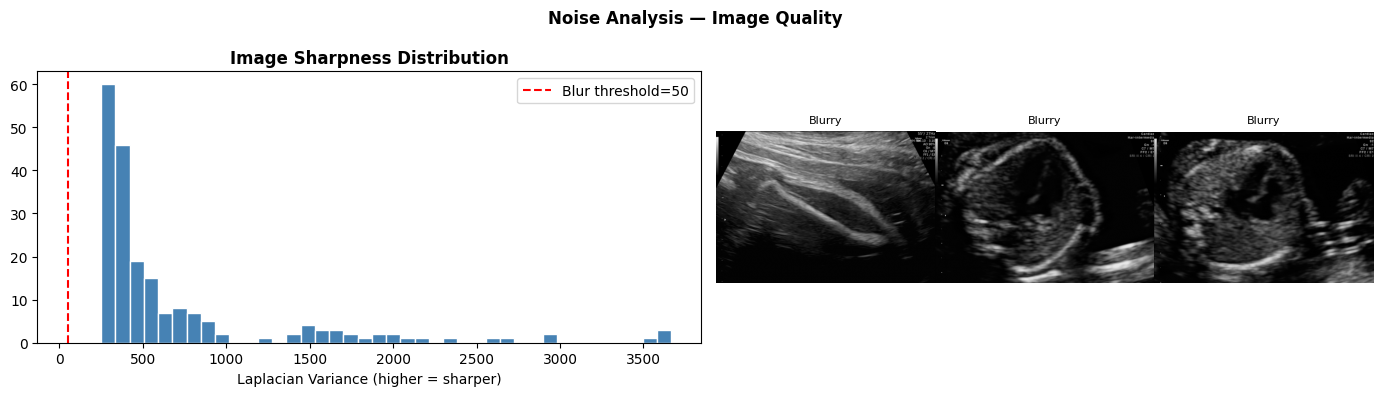


[Noise Handling Strategy]
  1. Blurry images    → Gaussian blur augmentation teaches robustness
  2. Noisy labels     → Label smoothing (ε=0.1) prevents overconfidence
  3. Class imbalance  → WeightedRandomSampler + class-weighted loss
  4. Background noise → Random crop + color jitter augmentation
  5. Outliers         → High-loss sample monitoring during training


In [ ]:
# NOISE HANDLING

print("NOISE DETECTION & HANDLING")

# Detect blurry images (Laplacian variance)
print("\n[Blur Detection] Checking image sharpness...")
def blur_score(fp, threshold=50):
    img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
    if img is None: return 0
    return cv2.Laplacian(img, cv2.CV_64F).var()

sample_fps = df['filepath'].sample(200, random_state=42).tolist()
scores     = [blur_score(fp) for fp in sample_fps]
blurry     = [fp for fp, s in zip(sample_fps, scores) if s < 50]

print(f"  Mean sharpness score : {np.mean(scores):.1f}")
print(f"  Blurry samples (<50) : {len(blurry)} out of 200 sampled")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(scores, bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(x=50, color='red', linestyle='--', label='Blur threshold=50')
axes[0].set_title('Image Sharpness Distribution', fontweight='bold')
axes[0].set_xlabel('Laplacian Variance (higher = sharper)')
axes[0].legend()

# Show blurriest vs sharpest
sorted_pairs = sorted(zip(scores, sample_fps))
worst_fps    = [fp for _, fp in sorted_pairs[:3]]
best_fps     = [fp for _, fp in sorted_pairs[-3:]]

comparison_fps   = worst_fps + best_fps
comparison_titles = ['Blurry']*3 + ['Sharp']*3
ax2 = axes[1]
ax2.axis('off')
for i, (fp, title) in enumerate(zip(comparison_fps[:3], comparison_titles[:3])):
    inset = ax2.inset_axes([i*0.33, 0, 0.33, 1])
    inset.imshow(Image.open(fp), cmap='gray')
    inset.set_title(title, fontsize=8)
    inset.axis('off')

plt.suptitle('Noise Analysis — Image Quality', fontweight='bold')
plt.tight_layout()
plt.savefig('noise_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n[Noise Handling Strategy]")
print("  1. Blurry images    → Gaussian blur augmentation teaches robustness")
print("  2. Noisy labels     → Label smoothing (ε=0.1) prevents overconfidence")
print("  3. Class imbalance  → WeightedRandomSampler + class-weighted loss")
print("  4. Background noise → Random crop + color jitter augmentation")
print("  5. Outliers         → High-loss sample monitoring during training")

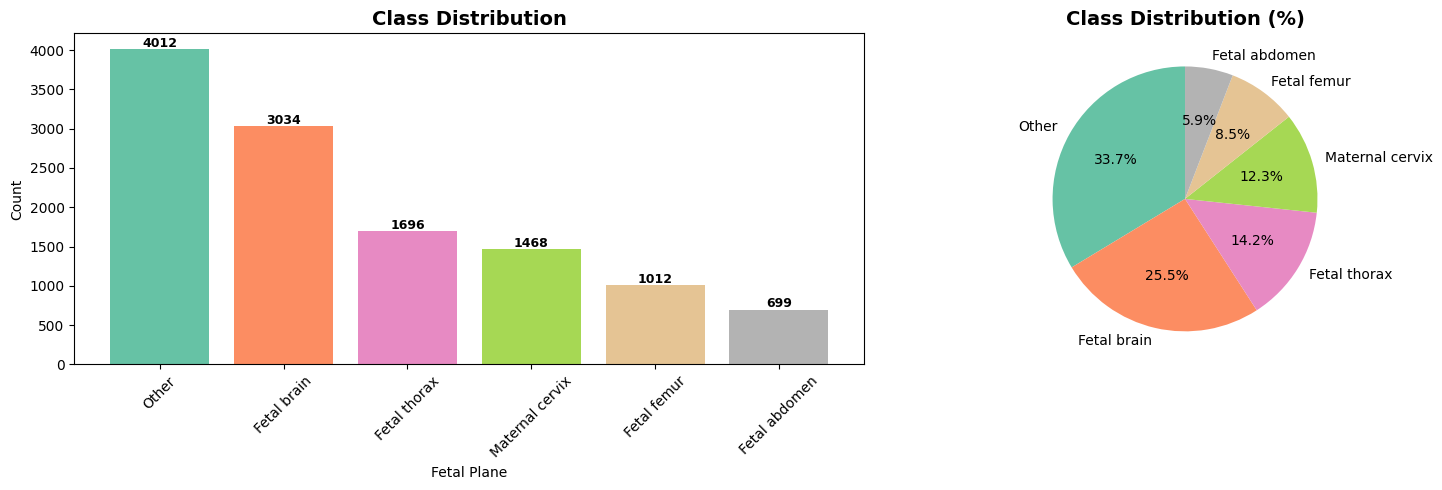

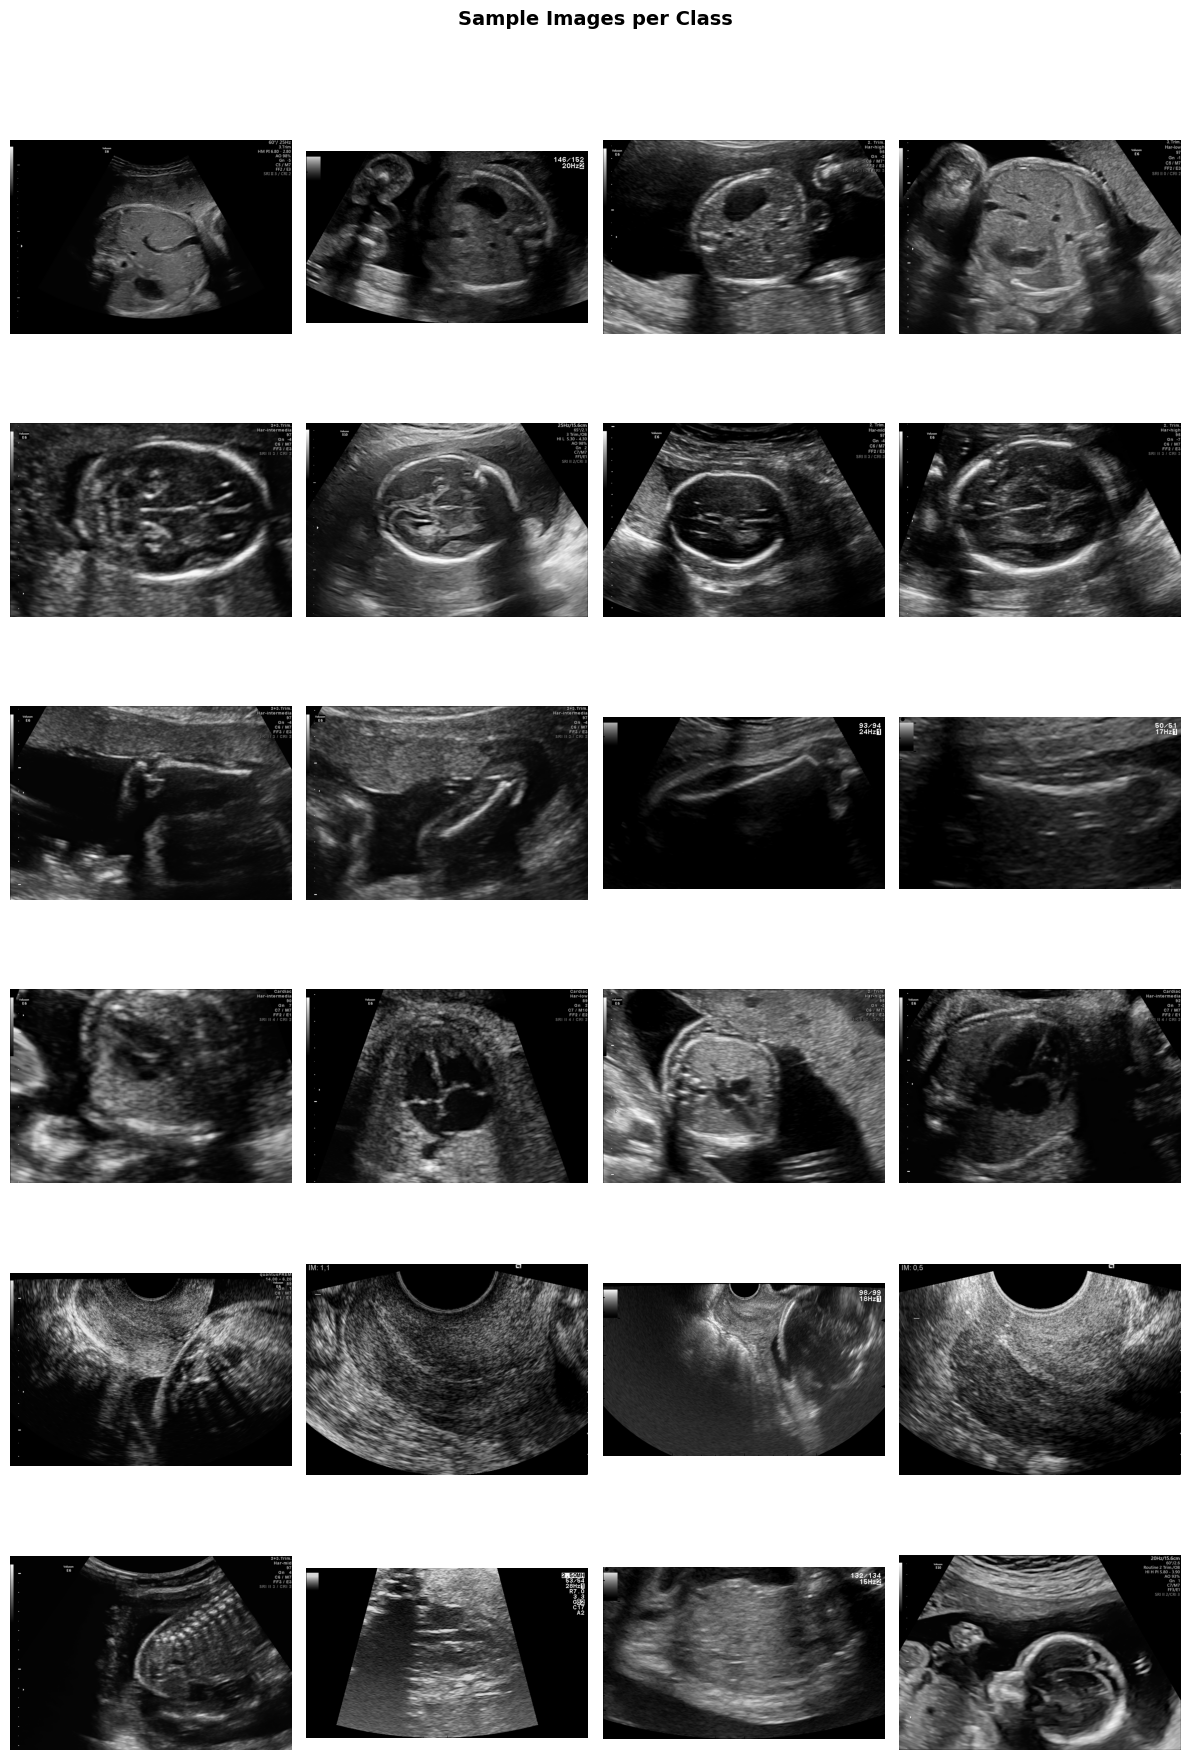

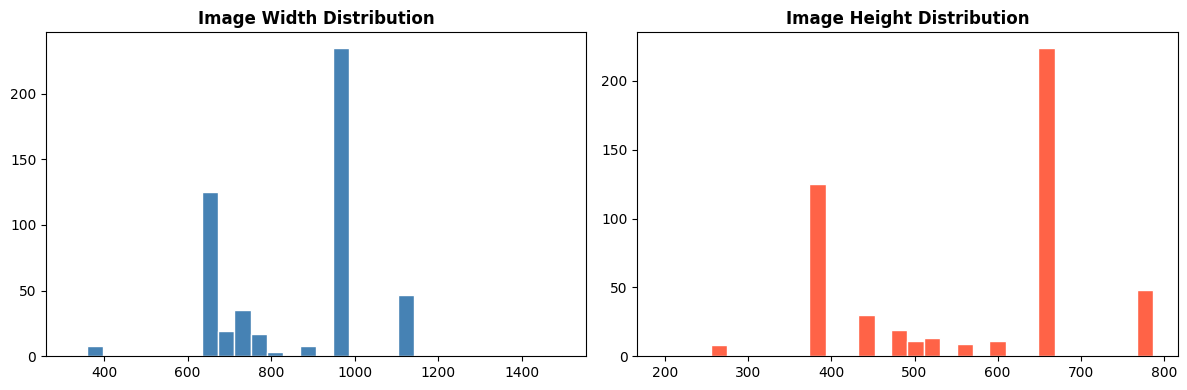

 EDA complete — 3 plots saved


In [ ]:
# EDA & VISUALISATION

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts = df['plane'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(counts)))

bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fetal Plane'); axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 30,
                 str(v), ha='center', fontweight='bold', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Sample images per class
n = 4
fig, axes = plt.subplots(NUM_CLASSES, n, figsize=(n*3, NUM_CLASSES*3))
for row, cls in enumerate(CLASSES):
    samples = df[df['plane']==cls].sample(n=n, random_state=42)
    for col, (_, r) in enumerate(samples.iterrows()):
        img = Image.open(r['filepath']).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(cls, fontsize=8,
                fontweight='bold', color='darkblue')
plt.suptitle('Sample Images per Class', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

# Image size distribution
widths, heights = [], []
for fp in df['filepath'].sample(500, random_state=42):
    w, h = Image.open(fp).size
    widths.append(w); heights.append(h)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths,  bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution',  fontweight='bold')
axes[1].hist(heights, bins=30, color='tomato',   edgecolor='white')
axes[1].set_title('Image Height Distribution', fontweight='bold')
plt.tight_layout()
plt.savefig('image_size_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(" EDA complete — 3 plots saved")

In [ ]:
#STRATIFIED TRAIN / VAL / TEST SPLIT

train_full_df = df[df['train'] == 1].reset_index(drop=True)
test_df       = df[df['train'] == 0].reset_index(drop=True)

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=42)
for train_idx, val_idx in sss.split(train_full_df, train_full_df['label']):
    final_train_df = train_full_df.iloc[train_idx].reset_index(drop=True)
    val_df         = train_full_df.iloc[val_idx].reset_index(drop=True)

print(f" Train : {len(final_train_df)} samples")
print(f" Val   : {len(val_df)} samples")
print(f" Test  : {len(test_df)} samples")

print("\nClass distribution across splits:")
for name, split in [('Train', final_train_df),
                    ('Val',   val_df),
                    ('Test',  test_df)]:
    pct = split['plane'].value_counts(normalize=True)*100
    print(f"\n  {name}:")
    for cls, p in pct.items():
        print(f"    {cls:<20}: {p:.1f}%")

 Train : 6186 samples
 Val   : 688 samples
 Test  : 5047 samples

Class distribution across splits:

  Train:
    Other               : 36.3%
    Fetal brain         : 23.3%
    Fetal thorax        : 15.2%
    Maternal cervix     : 12.7%
    Fetal femur         : 7.4%
    Fetal abdomen       : 5.1%

  Val:
    Other               : 36.3%
    Fetal brain         : 23.3%
    Fetal thorax        : 15.3%
    Maternal cervix     : 12.6%
    Fetal femur         : 7.4%
    Fetal abdomen       : 5.1%

  Test:
    Other               : 30.0%
    Fetal brain         : 28.4%
    Fetal thorax        : 12.9%
    Maternal cervix     : 11.8%
    Fetal femur         : 9.9%
    Fetal abdomen       : 6.9%


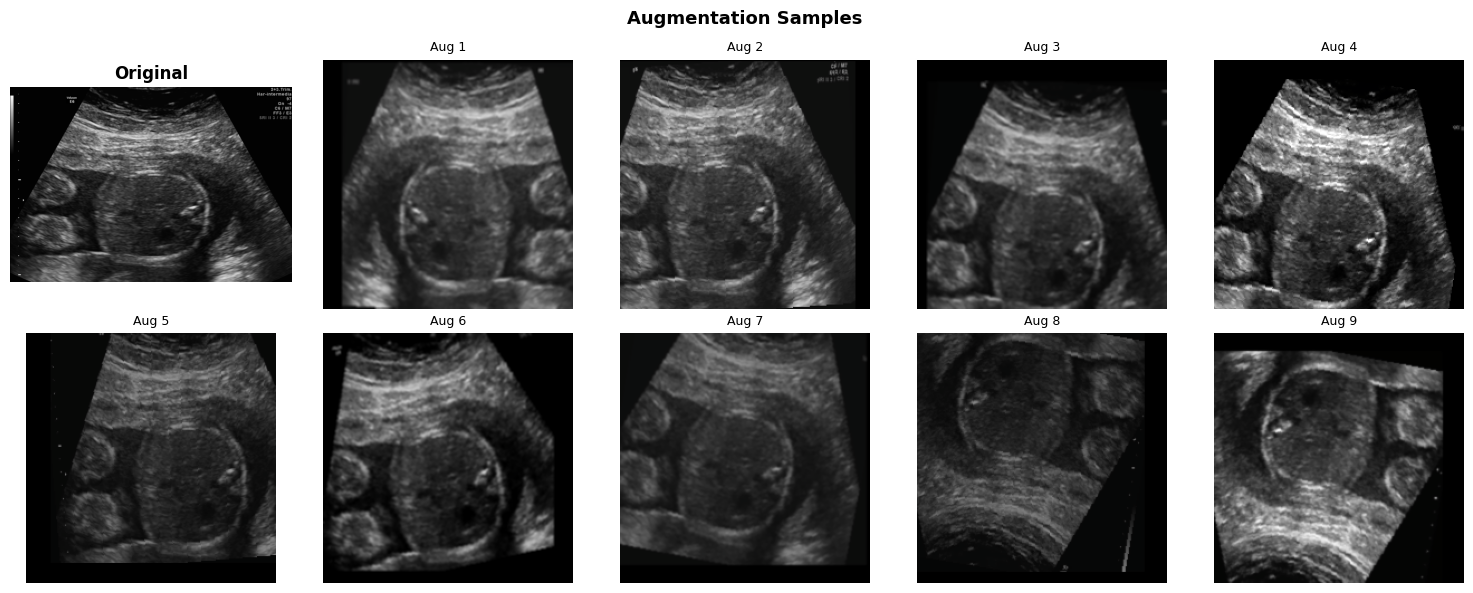

Augmentation pipeline ready


In [ ]:
# PREPROCESSING & AUGMENTATION PIPELINE

IMG_SIZE = CFG['img_size']
MEAN     = CFG['mean']
STD      = CFG['std']

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE+20, IMG_SIZE+20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),
    transforms.RandomAffine(degrees=0,
                            translate=(0.1, 0.1)),
    transforms.GaussianBlur(kernel_size=3,
                            sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

# Visualise augmentation effect
sample_img = Image.open(final_train_df['filepath'].iloc[0]).convert('RGB')
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes[0, 0].imshow(sample_img, cmap='gray')
axes[0, 0].set_title('Original', fontweight='bold')
axes[0, 0].axis('off')
for i in range(1, 10):
    aug = train_transforms(sample_img).permute(1,2,0).numpy()
    aug = np.clip(aug * np.array(STD) + np.array(MEAN), 0, 1)
    r, c = divmod(i, 5)
    axes[r, c].imshow(aug)
    axes[r, c].set_title(f'Aug {i}', fontsize=9)
    axes[r, c].axis('off')
plt.suptitle('Augmentation Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Augmentation pipeline ready")

In [ ]:
# DATASET CLASS & DATALOADERS

class FetalPlaneDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        try:
            image = Image.open(row['filepath']).convert('RGB')
        except Exception:
            # Return black image for any unreadable file
            image = Image.new('RGB', (CFG['img_size'], CFG['img_size']))
        if self.transform:
            image = self.transform(image)
        return image, int(row['label'])

def make_weighted_sampler(df):
    counts  = df['label'].value_counts().sort_index().values
    weights = 1.0 / counts
    sw = df['label'].map({i: weights[i]
                          for i in range(len(counts))}).values
    return WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw), replacement=True)

counts_train  = final_train_df['label'].value_counts().sort_index().values
class_weights = torch.FloatTensor(1.0 / counts_train).to(DEVICE)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

BATCH = CFG['batch_size']
NW    = CFG['num_workers']

train_loader = DataLoader(
    FetalPlaneDataset(final_train_df, train_transforms),
    BATCH, sampler=make_weighted_sampler(final_train_df),
    num_workers=NW, pin_memory=True)

val_loader = DataLoader(
    FetalPlaneDataset(val_df, val_transforms),
    BATCH, shuffle=False, num_workers=NW)

test_loader = DataLoader(
    FetalPlaneDataset(test_df, val_transforms),
    BATCH, shuffle=False, num_workers=NW)

print(f" Train : {len(final_train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")
print(f" Class weights : {class_weights.cpu().numpy().round(3)}")

 Train : 6186 | Val : 688 | Test : 5047
 Class weights : [2.157 0.472 1.48  0.724 0.865 0.303]


In [ ]:
# MODEL BUILDER (EfficientNet-B0 + ResNet-50)

def build_efficientnet(num_classes, freeze=True):
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    if freeze:
        for p in model.parameters(): p.requires_grad = False
        for p in model.features[-2:].parameters(): p.requires_grad = True
    in_f = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(CFG['dropout1']),
        nn.Linear(in_f, 512),
        nn.ReLU(),
        nn.Dropout(CFG['dropout2']),
        nn.Linear(512, num_classes)
    )
    return model

def build_resnet50(num_classes, freeze=True):
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    if freeze:
        for p in model.parameters(): p.requires_grad = False
        for p in model.layer4.parameters(): p.requires_grad = True
    in_f = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(CFG['dropout1']),
        nn.Linear(in_f, 512),
        nn.ReLU(),
        nn.Dropout(CFG['dropout2']),
        nn.Linear(512, num_classes)
    )
    return model

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

eff_model = build_efficientnet(NUM_CLASSES).to(DEVICE)
res_model = build_resnet50(NUM_CLASSES).to(DEVICE)

t, tr = count_params(eff_model)
print(f"EfficientNet-B0 → Total: {t:,} | Trainable: {tr:,}")
t, tr = count_params(res_model)
print(f"ResNet-50       → Total: {t:,} | Trainable: {tr:,}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 112MB/s] 


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


EfficientNet-B0 → Total: 4,666,498 | Trainable: 1,788,342
ResNet-50       → Total: 24,560,198 | Trainable: 16,016,902


In [ ]:
# TRAINING ENGINE

def make_criterion():
    return nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=CFG['label_smoothing'])

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, lbls in loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(lbls).sum().item()
        total    += imgs.size(0)
    return loss_sum/total, correct/total

def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out   = model(imgs)
            loss  = criterion(out, lbls)
            probs = torch.softmax(out, 1)
            preds = out.argmax(1)
            loss_sum += loss.item() * imgs.size(0)
            correct  += preds.eq(lbls).sum().item()
            total    += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(lbls.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return loss_sum/total, correct/total, all_preds, all_labels, all_probs

class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
                print(f"   Early stopping triggered after {self.patience} epochs")
        else:
            self.best_score = val_acc
            self.counter    = 0

def run_training(model, model_name, save_path):
    criterion   = make_criterion()
    es          = EarlyStopping(patience=CFG['patience'])
    best_val    = 0.0
    history     = {'tl':[], 'vl':[], 'ta':[], 'va':[]}

    EPOCHS_F  = CFG['epochs_frozen']
    EPOCHS_UF = CFG['epochs_unfrozen']

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG['lr_head'], weight_decay=CFG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS_F, eta_min=1e-6)

    print(f"\n{'='*60}")
    print(f"Training {model_name}")
    print(f"{'='*60}")
    print(f"Phase 1 — Head only (backbone frozen, {EPOCHS_F} epochs)")
    print(f"{'='*60}")

    for epoch in range(1, EPOCHS_F + EPOCHS_UF + 1):
        if epoch == EPOCHS_F + 1:
            print(f"\n{'='*60}")
            print(f"Phase 2 — Full fine-tune (backbone unfrozen, {EPOCHS_UF} epochs)")
            print(f"{'='*60}")
            for p in model.parameters(): p.requires_grad = True
            optimizer = optim.AdamW(
                model.parameters(),
                lr=CFG['lr_finetune'], weight_decay=CFG['weight_decay'])
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS_UF, eta_min=1e-7)

        tl, ta = train_epoch(model, train_loader, optimizer, criterion)
        vl, va, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['tl'].append(tl); history['ta'].append(ta)
        history['vl'].append(vl); history['va'].append(va)

        flag = ""
        if va > best_val:
            best_val = va
            torch.save(model.state_dict(), save_path)
            flag = "  BEST"

        print(f"  Epoch [{epoch:02d}/{EPOCHS_F+EPOCHS_UF}] "
              f"Loss {tl:.4f} Acc {ta:.4f} | "
              f"Val Loss {vl:.4f} Acc {va:.4f} | "
              f"LR {optimizer.param_groups[0]['lr']:.1e}{flag}")

        es(va)
        if es.stop: break

    print(f"\n   {model_name} Best Val Acc: {best_val:.4f}")
    return history, best_val

# Train EfficientNet-B0
eff_history, eff_best_val = run_training(
    eff_model, "EfficientNet-B0", "best_efficientnet.pth")

# Train ResNet-50
res_history, res_best_val = run_training(
    res_model, "ResNet-50", "best_resnet50.pth")


Training EfficientNet-B0
Phase 1 — Head only (backbone frozen, 5 epochs)
  Epoch [01/20] Loss 0.7418 Acc 0.7742 | Val Loss 0.8832 Acc 0.7936 | LR 9.0e-04  BEST
  Epoch [02/20] Loss 0.5760 Acc 0.8815 | Val Loss 0.7686 Acc 0.8881 | LR 6.5e-04  BEST
  Epoch [03/20] Loss 0.5198 Acc 0.9138 | Val Loss 0.7634 Acc 0.8881 | LR 3.5e-04
  Epoch [04/20] Loss 0.5017 Acc 0.9192 | Val Loss 0.7360 Acc 0.8953 | LR 9.6e-05  BEST
  Epoch [05/20] Loss 0.4948 Acc 0.9219 | Val Loss 0.7177 Acc 0.9041 | LR 1.0e-06  BEST

Phase 2 — Full fine-tune (backbone unfrozen, 15 epochs)
  Epoch [06/20] Loss 0.4897 Acc 0.9295 | Val Loss 0.7010 Acc 0.9157 | LR 4.9e-05  BEST
  Epoch [07/20] Loss 0.4598 Acc 0.9492 | Val Loss 0.6997 Acc 0.9157 | LR 4.8e-05
  Epoch [08/20] Loss 0.4586 Acc 0.9504 | Val Loss 0.6644 Acc 0.9346 | LR 4.5e-05  BEST
  Epoch [09/20] Loss 0.4524 Acc 0.9531 | Val Loss 0.6744 Acc 0.9302 | LR 4.2e-05
  Epoch [10/20] Loss 0.4407 Acc 0.9612 | Val Loss 0.6687 Acc 0.9331 | LR 3.8e-05
  Epoch [11/20] Loss 0.

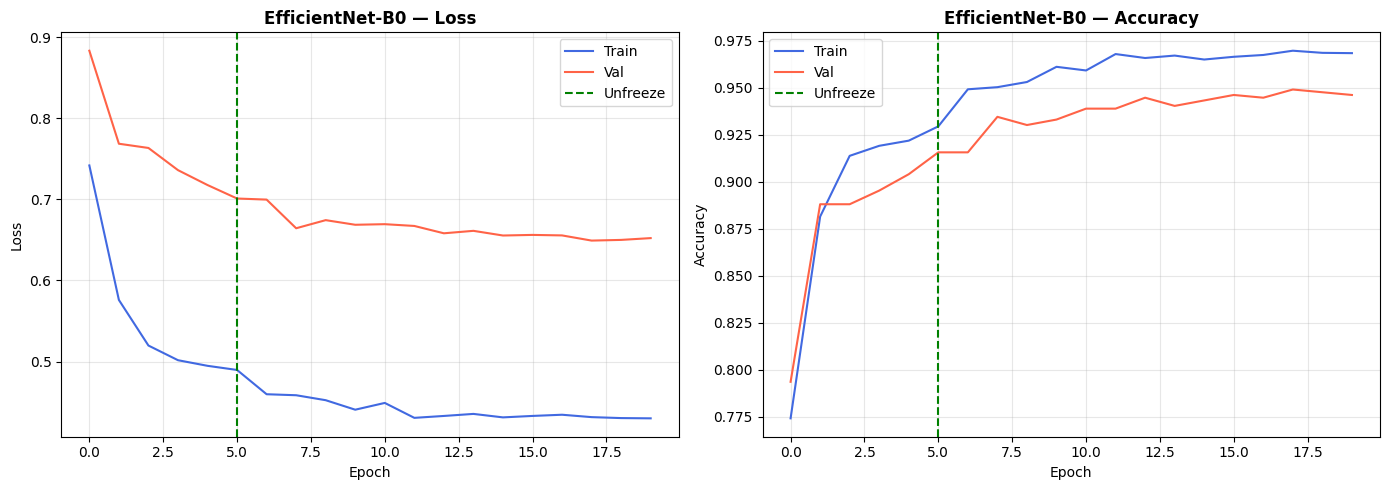

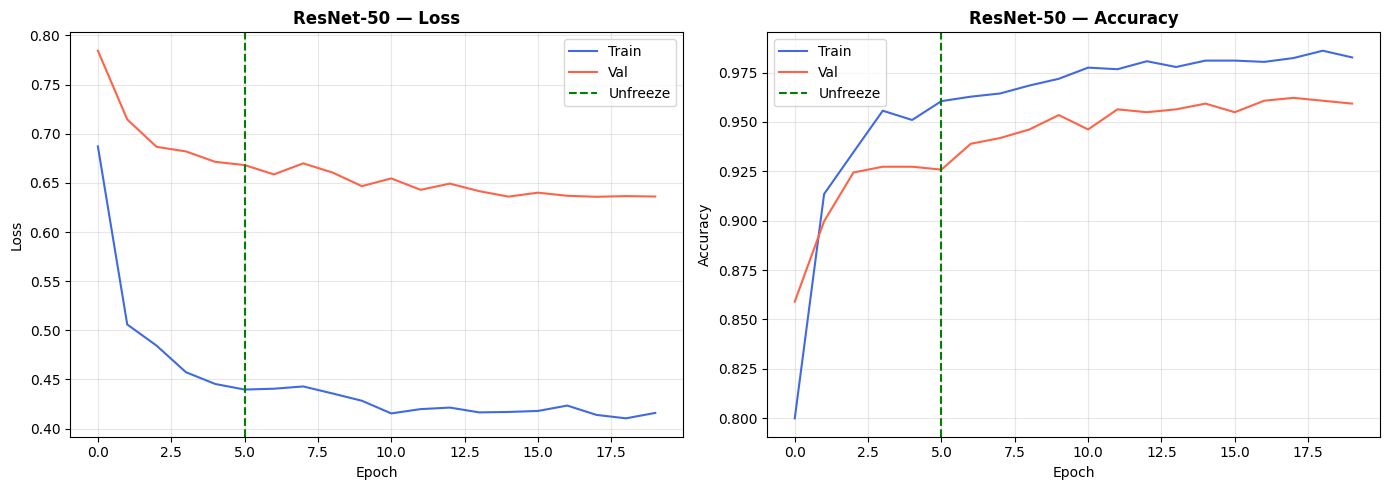

In [ ]:
# TRAINING CURVES
def plot_curves(history, title, save_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ef = CFG['epochs_frozen']

    axes[0].plot(history['tl'], label='Train', color='royalblue')
    axes[0].plot(history['vl'], label='Val',   color='tomato')
    axes[0].axvline(x=ef, color='green', linestyle='--', label='Unfreeze')
    axes[0].set_title(f'{title} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['ta'], label='Train', color='royalblue')
    axes[1].plot(history['va'], label='Val',   color='tomato')
    axes[1].axvline(x=ef, color='green', linestyle='--', label='Unfreeze')
    axes[1].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_curves(eff_history, 'EfficientNet-B0', 'curves_efficientnet.png')
plot_curves(res_history, 'ResNet-50',        'curves_resnet50.png')

In [ ]:
#TEST EVALUATION
def full_evaluation(model, weights_path, model_name):
    model.load_state_dict(torch.load(weights_path))
    criterion = make_criterion()
    loss, acc, preds, labels, probs = evaluate(model, test_loader, criterion)

    probs_np   = np.array(probs)
    labels_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))
    macro_auc  = roc_auc_score(labels_bin, probs_np,
                                average='macro', multi_class='ovr')

    print(f"\n{'='*55}")
    print(f"TEST RESULTS — {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc*100:.2f}%")
    print(f"  Macro F1      : {f1_score(labels, preds, average='macro'):.4f}")
    print(f"  Macro Recall  : {recall_score(labels, preds, average='macro'):.4f}")
    print(f"  Macro Precision: {precision_score(labels, preds, average='macro'):.4f}")
    print(f"  Macro AUC     : {macro_auc:.4f}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"\n  Per-class report:")
    print(classification_report(labels, preds,
                                 target_names=CLASSES, digits=4))
    return acc, macro_auc, preds, labels, probs_np, labels_bin

(eff_acc, eff_auc, eff_preds, eff_labels,
 eff_probs, eff_lbin) = full_evaluation(
    eff_model, 'best_efficientnet.pth', 'EfficientNet-B0')

(res_acc, res_auc, res_preds, res_labels,
 res_probs, res_lbin) = full_evaluation(
    res_model, 'best_resnet50.pth', 'ResNet-50')


TEST RESULTS — EfficientNet-B0
  Accuracy      : 90.53%
  Macro F1      : 0.8991
  Macro Recall  : 0.9404
  Macro Precision: 0.8784
  Macro AUC     : 0.9900
  Test Loss     : 0.6860

  Per-class report:
                 precision    recall  f1-score   support

  Fetal abdomen     0.7561    0.9771    0.8525       349
    Fetal brain     0.9814    0.9930    0.9872      1433
    Fetal femur     0.7031    0.9861    0.8209       502
   Fetal thorax     0.8663    0.9739    0.9170       652
Maternal cervix     0.9867    1.0000    0.9933       595
          Other     0.9765    0.7124    0.8238      1516

       accuracy                         0.9053      5047
      macro avg     0.8784    0.9404    0.8991      5047
   weighted avg     0.9224    0.9053    0.9039      5047


TEST RESULTS — ResNet-50
  Accuracy      : 93.66%
  Macro F1      : 0.9323
  Macro Recall  : 0.9532
  Macro Precision: 0.9168
  Macro AUC     : 0.9913
  Test Loss     : 0.6580

  Per-class report:
                 precisio

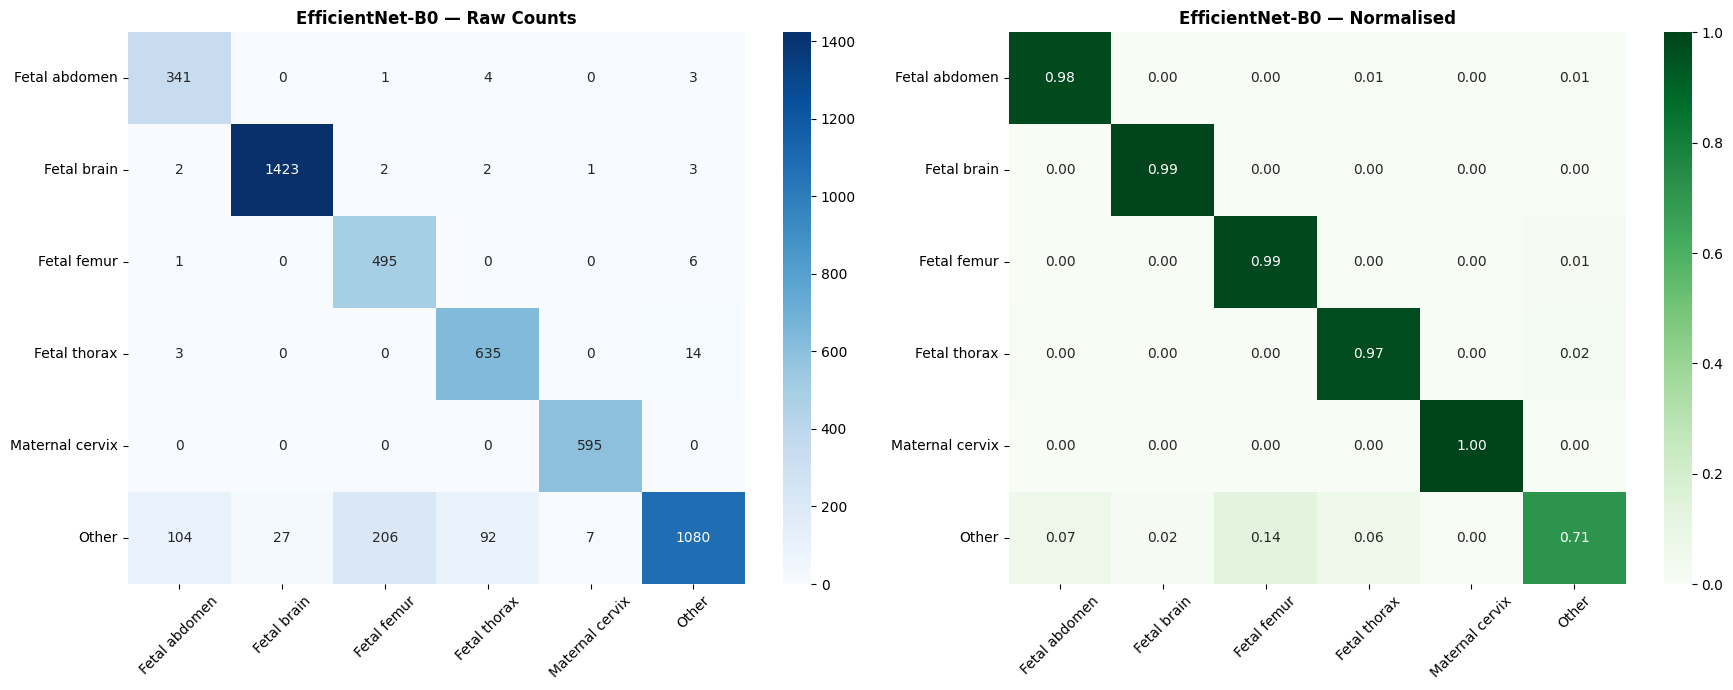

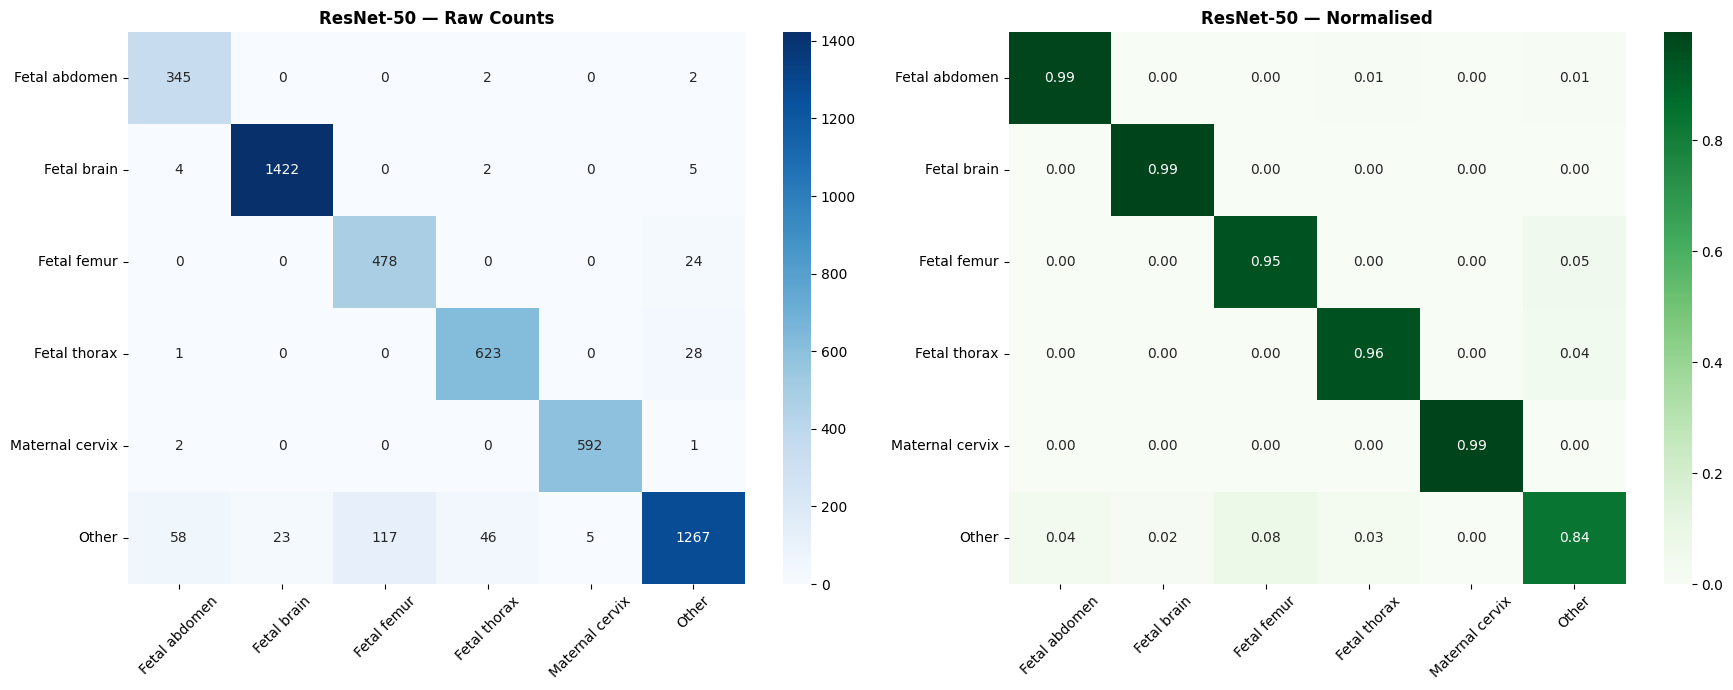

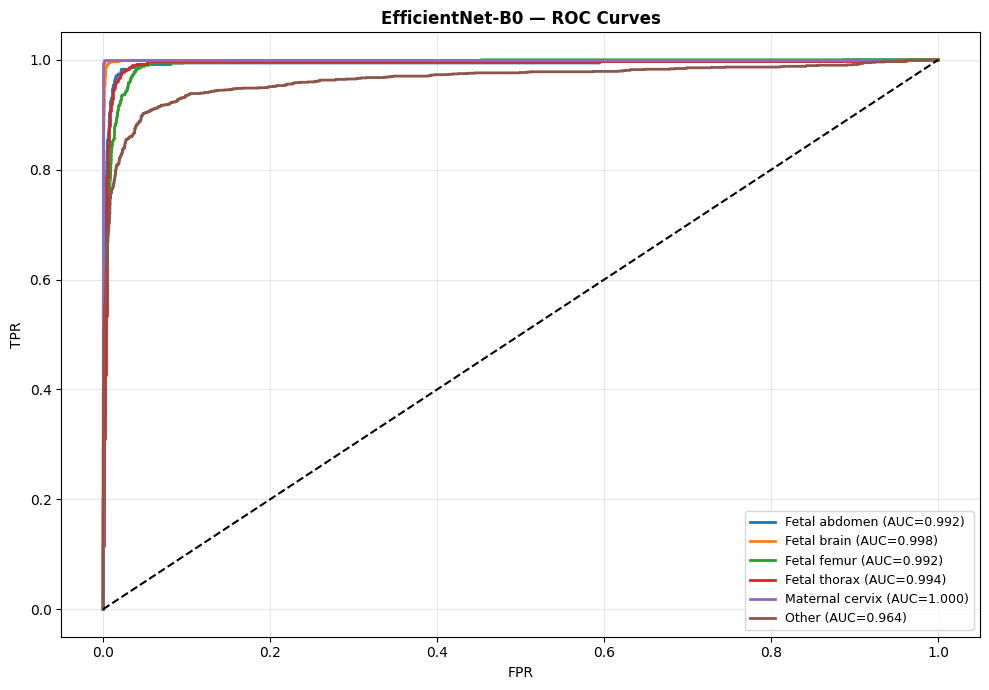

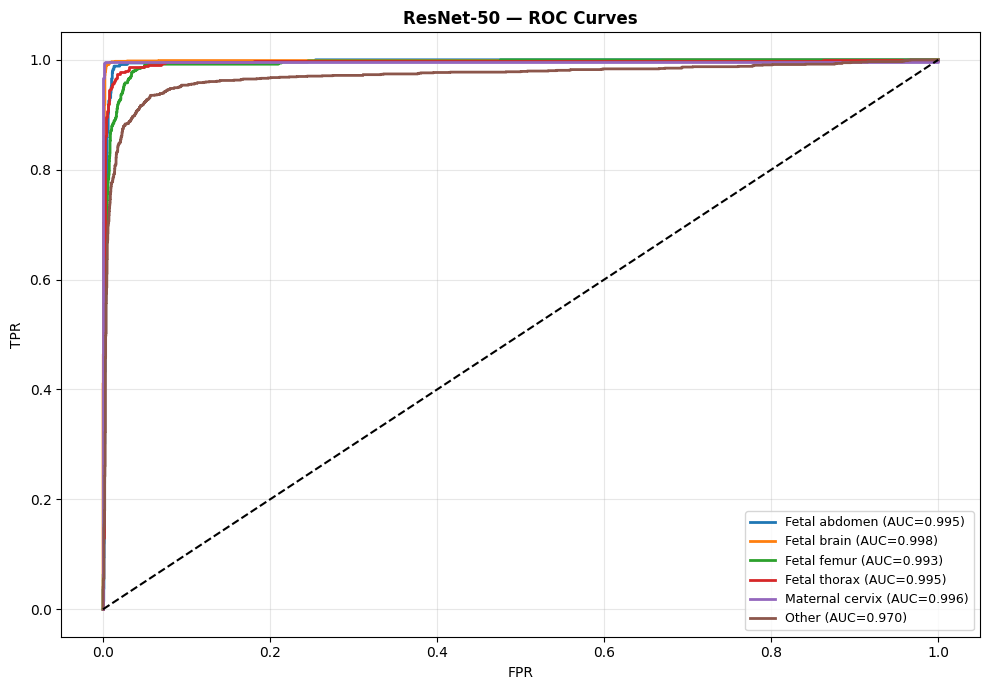

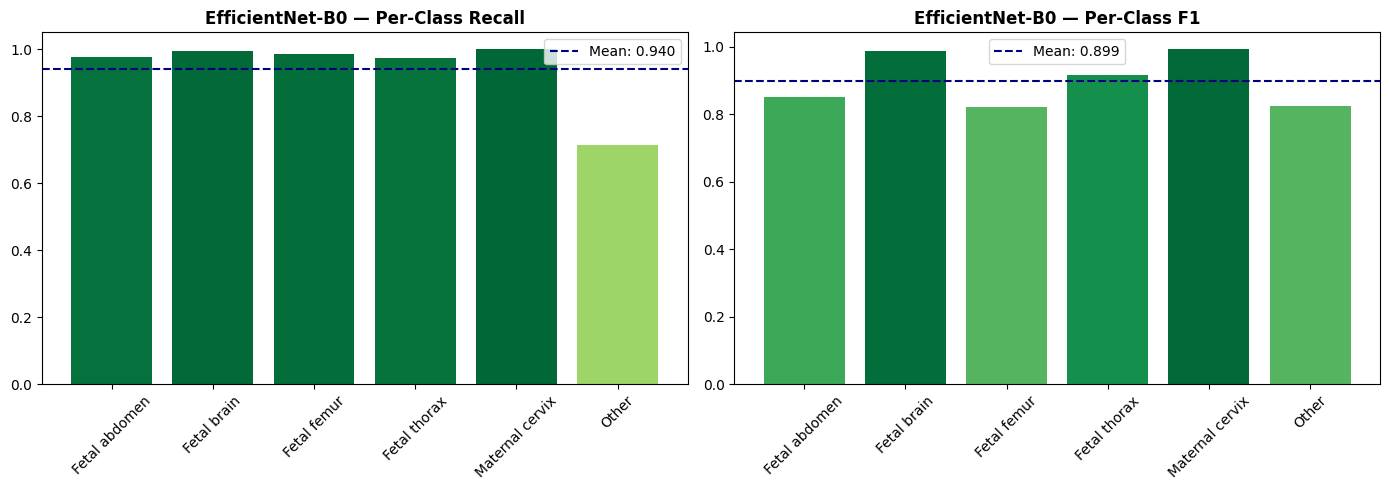

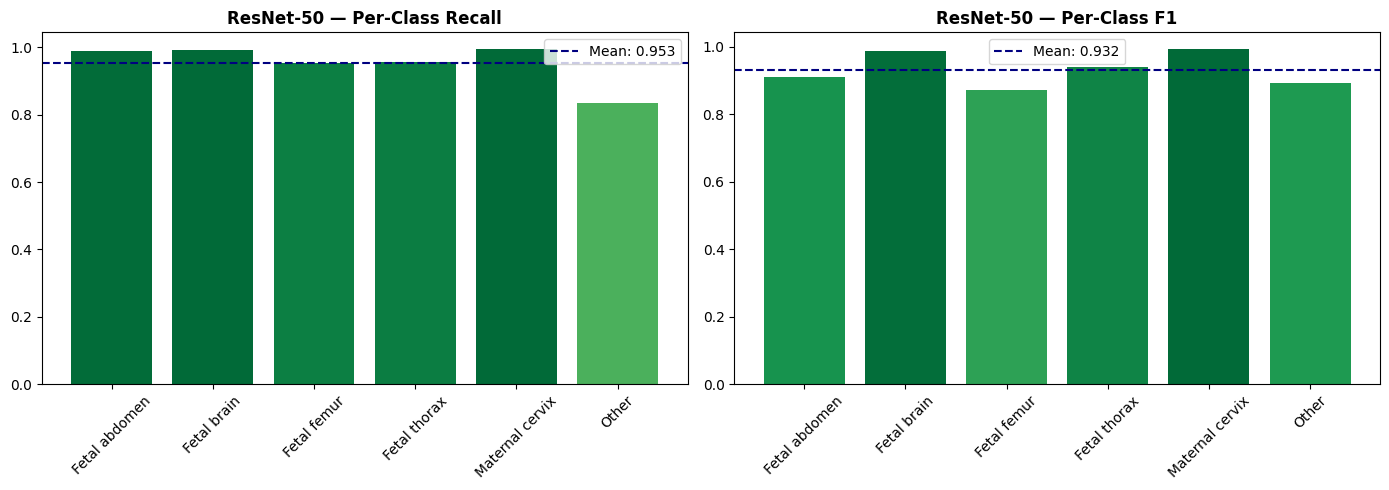

In [ ]:
# VISUALISATIONS

def plot_confusion(preds, labels, title, save_name):
    cm_raw  = confusion_matrix(labels, preds)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm_raw,  annot=True, fmt='d',   cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title(f'{title} — Raw Counts', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title(f'{title} — Normalised', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion(eff_preds, eff_labels,
               'EfficientNet-B0', 'cm_efficientnet.png')
plot_confusion(res_preds, res_labels,
               'ResNet-50',       'cm_resnet50.png')

def plot_roc(probs, labels_bin, title, save_name):
    fig, ax = plt.subplots(figsize=(10, 7))
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
        auc = roc_auc_score(labels_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=2, label=f"{cls} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'k--', lw=1.5)
    ax.set_title(f'{title} — ROC Curves', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_roc(eff_probs, eff_lbin, 'EfficientNet-B0', 'roc_efficientnet.png')
plot_roc(res_probs, res_lbin, 'ResNet-50',        'roc_resnet50.png')

def plot_per_class(preds, labels, title, save_name):
    rep = classification_report(labels, preds,
                                  target_names=CLASSES, output_dict=True)
    f1s  = [rep[c]['f1-score'] for c in CLASSES]
    recs = [rep[c]['recall']   for c in CLASSES]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(CLASSES, recs, color=plt.cm.RdYlGn(np.array(recs)))
    axes[0].axhline(np.mean(recs), color='navy', linestyle='--',
                    label=f'Mean: {np.mean(recs):.3f}')
    axes[0].set_title(f'{title} — Per-Class Recall', fontweight='bold')
    axes[0].tick_params(axis='x', rotation=45); axes[0].legend()
    axes[1].bar(CLASSES, f1s, color=plt.cm.RdYlGn(np.array(f1s)))
    axes[1].axhline(np.mean(f1s), color='navy', linestyle='--',
                    label=f'Mean: {np.mean(f1s):.3f}')
    axes[1].set_title(f'{title} — Per-Class F1', fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45); axes[1].legend()
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches='tight')
    plt.show()

plot_per_class(eff_preds, eff_labels,
               'EfficientNet-B0', 'perclass_efficientnet.png')
plot_per_class(res_preds, res_labels,
               'ResNet-50',       'perclass_resnet50.png')

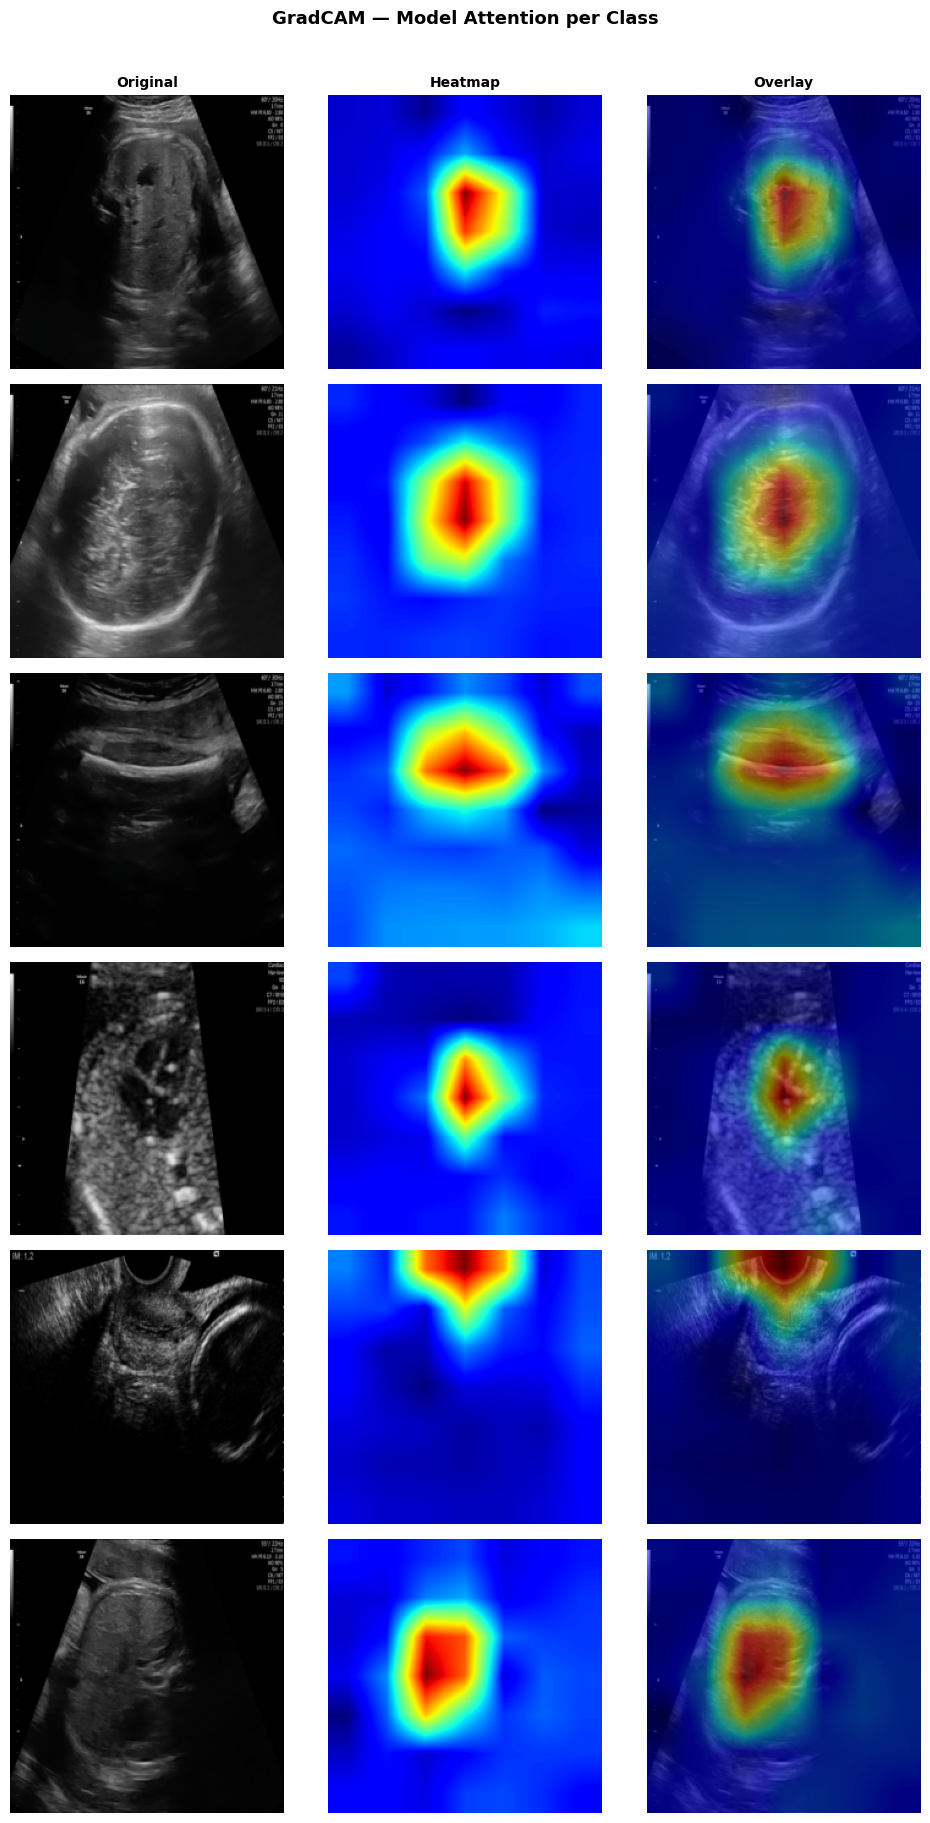

GradCAM saved


In [ ]:
# GRADCAM EXPLAINABILITY
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.grads = None
        self.acts  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'acts', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'grads', go[0].detach()))

    def generate(self, x, class_idx=None):
        self.model.eval()
        out = self.model(x)
        if class_idx is None: class_idx = out.argmax(1).item()
        self.model.zero_grad()
        out[0, class_idx].backward()
        w   = self.grads.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w * self.acts).sum(1)).squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

eff_model.load_state_dict(torch.load('best_efficientnet.pth'))
gradcam = GradCAM(eff_model, eff_model.features[-1])

fig, axes = plt.subplots(NUM_CLASSES, 3,
                          figsize=(10, NUM_CLASSES * 3))
fig.suptitle('GradCAM — Model Attention per Class',
              fontsize=13, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASSES):
    sample = test_df[test_df['plane'] == cls].iloc[0]
    img    = Image.open(sample['filepath']).convert('RGB')
    img_t  = val_transforms(img).unsqueeze(0).to(DEVICE)

    cam, pred = gradcam.generate(img_t)
    img_np    = np.clip(
        img_t.squeeze().permute(1,2,0).cpu().numpy()
        * np.array(STD) + np.array(MEAN), 0, 1)
    cam_r    = cv2.resize(cam, (CFG['img_size'], CFG['img_size']))
    heatmap  = cm.jet(cam_r)[:,:,:3]
    overlay  = np.clip(0.5*heatmap + 0.5*img_np, 0, 1)

    axes[row,0].imshow(img_np); axes[row,0].axis('off')
    axes[row,1].imshow(cm.jet(cam_r)); axes[row,1].axis('off')
    axes[row,2].imshow(overlay); axes[row,2].axis('off')
    axes[row,0].set_ylabel(cls, fontsize=8, color='darkblue',
                            fontweight='bold')
    if row == 0:
        for c, t in enumerate(['Original','Heatmap','Overlay']):
            axes[0,c].set_title(t, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
print("GradCAM saved")

        Metric EfficientNet-B0 ResNet-50
 Test Accuracy          90.53%    93.66%
     Macro AUC          0.9900    0.9913
  Best Val Acc          94.91%    96.22%
    Parameters           ~5.3M    ~25.6M
Training Speed          Faster    Slower


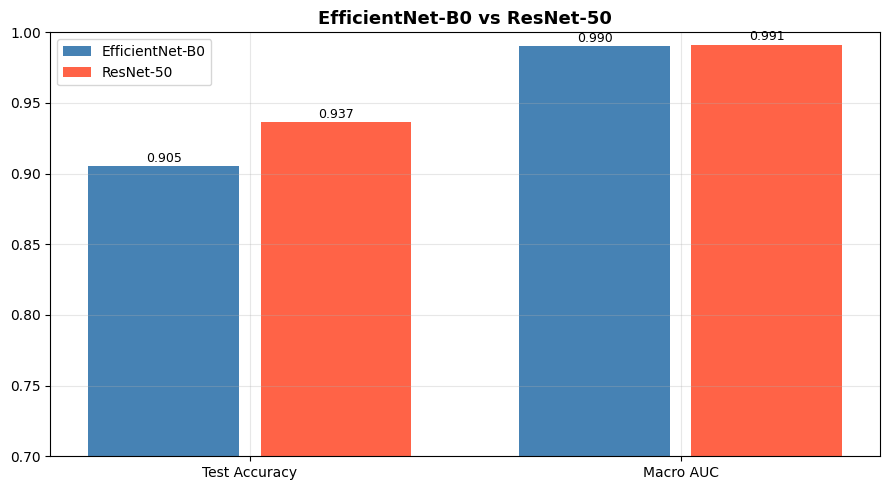

In [ ]:
# MODEL COMPARISON TABLE

comparison = pd.DataFrame({
    'Metric': ['Test Accuracy', 'Macro AUC', 'Best Val Acc',
               'Parameters', 'Training Speed'],
    'EfficientNet-B0': [
        f"{eff_acc*100:.2f}%", f"{eff_auc:.4f}",
        f"{eff_best_val*100:.2f}%", "~5.3M", "Faster"],
    'ResNet-50': [
        f"{res_acc*100:.2f}%", f"{res_auc:.4f}",
        f"{res_best_val*100:.2f}%", "~25.6M", "Slower"],
})
print(comparison.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
metrics = ['Test Accuracy', 'Macro AUC']
x = np.arange(len(metrics))
ax.bar(x-0.2, [eff_acc, eff_auc], 0.35,
       label='EfficientNet-B0', color='steelblue')
ax.bar(x+0.2, [res_acc, res_auc], 0.35,
       label='ResNet-50',       color='tomato')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.7, 1.0)
ax.set_title('EfficientNet-B0 vs ResNet-50', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.003),
                ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Testing on: /content/fetal_data/Images/Patient01307_Plane1_18_of_25.png


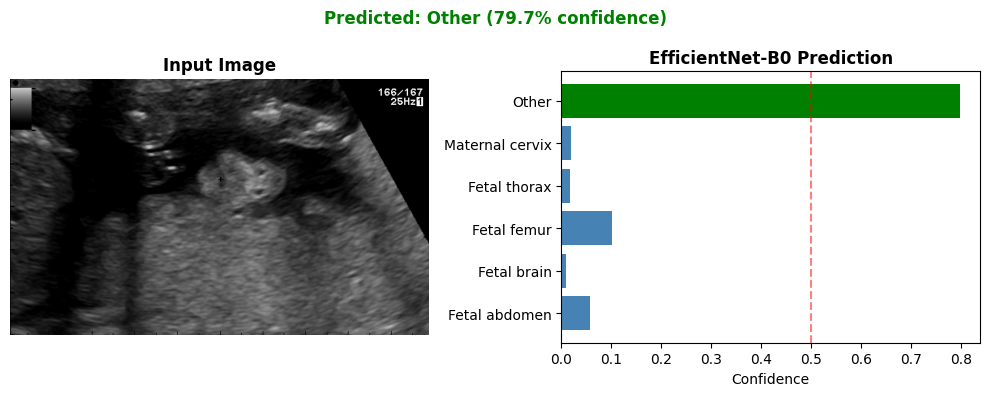


 Prediction: Other
 Confidence: 79.7%
   Fetal abdomen       : 5.6%
   Fetal brain         : 0.9%
   Fetal femur         : 10.1%
   Fetal thorax        : 1.8%
   Maternal cervix     : 1.8%
   Other               : 79.7%


('Other',
 array([0.05647583, 0.00877346, 0.10069528, 0.01816786, 0.01839184,
        0.7974957 ], dtype=float32))

In [ ]:

#  IMAGE TESTING
def predict_single_image(image_path, model, model_name="Model"):
    """Test any single image — works on unseen images."""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        out   = model(tensor)
        probs = torch.softmax(out, 1).squeeze().cpu().numpy()
        pred  = probs.argmax()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f"Input Image", fontweight='bold')
    axes[0].axis('off')

    colors = ['green' if i == pred else 'steelblue'
               for i in range(NUM_CLASSES)]
    axes[1].barh(CLASSES, probs, color=colors)
    axes[1].set_title(f'{model_name} Prediction', fontweight='bold')
    axes[1].set_xlabel('Confidence')
    axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

    plt.suptitle(
        f"Predicted: {CLASSES[pred]} ({probs[pred]*100:.1f}% confidence)",
        fontsize=12, fontweight='bold', color='green')
    plt.tight_layout()
    plt.show()

    print(f"\n Prediction: {CLASSES[pred]}")
    print(f" Confidence: {probs[pred]*100:.1f}%")
    for cls, p in zip(CLASSES, probs):
        print(f"   {cls:<20}: {p*100:.1f}%")
    return CLASSES[pred], probs

# Test on a random test image
sample_path = test_df.sample(1, random_state=99)['filepath'].values[0]
print(f"Testing on: {sample_path}")
predict_single_image(sample_path, eff_model, "EfficientNet-B0")

In [ ]:
# SUMMARY

best_model      = eff_model if eff_acc >= res_acc else res_model
best_model_name = "EfficientNet-B0" if eff_acc >= res_acc else "ResNet-50"
best_acc        = max(eff_acc, res_acc)

torch.save({
    'model_state_dict' : best_model.state_dict(),
    'model_name'       : best_model_name,
    'class2idx'        : class2idx,
    'idx2class'        : idx2class,
    'classes'          : CLASSES,
    'num_classes'      : NUM_CLASSES,
    'test_accuracy'    : best_acc,
    'config'           : CFG,
}, 'fetal_classifier_final.pth')

print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)
print(f"  Dataset        : FETAL_PLANES_DB (Zenodo #3904280)")
print(f"  Total samples  : {len(df)}")
print(f"  Classes        : {NUM_CLASSES}")
print(f"  Train/Val/Test : {len(final_train_df)}/{len(val_df)}/{len(test_df)}")
print(f"")
print(f"  EfficientNet-B0 Test Acc : {eff_acc*100:.2f}%  AUC: {eff_auc:.4f}")
print(f"  ResNet-50       Test Acc : {res_acc*100:.2f}%  AUC: {res_auc:.4f}")
print(f"")
print(f"  Best model     : {best_model_name} ({best_acc*100:.2f}%)")
print(f"  Saved as       : fetal_classifier_final.pth")
print("="*60)


FINAL SUMMARY
  Dataset        : FETAL_PLANES_DB (Zenodo #3904280)
  Total samples  : 11921
  Classes        : 6
  Train/Val/Test : 6186/688/5047

  EfficientNet-B0 Test Acc : 90.53%  AUC: 0.9900
  ResNet-50       Test Acc : 93.66%  AUC: 0.9913

  Best model     : ResNet-50 (93.66%)
  Saved as       : fetal_classifier_final.pth


In [ ]:
# STREAMLIT

from google.colab import drive
drive.mount('/content/drive')

app_code = '''
import streamlit as st
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

CLASSES = ['Fetal abdomen', 'Fetal brain', 'Fetal femur',
           'Fetal thorax',  'Maternal cervix', 'Other']

DEVICE  = torch.device("cpu")

MODEL_PATHS = [
    "fetal_classifier_final.pth",
    "/content/fetal_classifier_final.pth",
    "/content/drive/MyDrive/fetal_classifier_final.pth"
]

def get_model_path():
    for path in MODEL_PATHS:
        if os.path.exists(path):
            return path
    raise FileNotFoundError(" Model file not found!")

@st.cache_resource
def load_model():
    model = efficientnet_b0(weights=None)
    in_f  = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_f, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, 6)
    )

    model_path = get_model_path()
    ckpt = torch.load(model_path, map_location=DEVICE)

    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    return model

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225]),
])

st.set_page_config(
    page_title="Fetal Ultrasound Classifier",
    page_icon="🔬",
    layout="centered"
)

st.title("🔬 Fetal Ultrasound Plane Classifier")
st.markdown("Upload a fetal ultrasound image to classify the anatomical plane.")

uploaded = st.file_uploader("Upload Image", type=["png","jpg","jpeg"])

if uploaded:
    img   = Image.open(uploaded).convert("RGB")
    model = load_model()

    col1, col2 = st.columns(2)

    with col1:
        st.image(img, caption="Uploaded Image", use_column_width=True)

    tensor = transform(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        probs = torch.softmax(model(tensor), 1).squeeze().numpy()

    pred = probs.argmax()

    with col2:
        st.subheader("Prediction")
        st.success(f"**{CLASSES[pred]}**")
        st.metric("Confidence", f"{probs[pred]*100:.1f}%")

        st.subheader("All Class Probabilities")
        for cls, p in zip(CLASSES, probs):
            st.progress(float(p), text=f"{cls}: {p*100:.1f}%")

    fig, ax = plt.subplots(figsize=(6, 3))

    colors = ["green" if i == pred else "steelblue"
              for i in range(len(CLASSES))]

    ax.barh(CLASSES, probs, color=colors)
    ax.set_xlabel("Confidence")
    ax.set_title("Class Probabilities")

    st.pyplot(fig)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

drive_path = "/content/drive/MyDrive/app.py"

with open(drive_path, 'w') as f:
    f.write(app_code)

print(" Saved in Colab: /content/app.py")
print(" Saved in Drive:", drive_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Saved in Colab: /content/app.py
 Saved in Drive: /content/drive/MyDrive/app.py


In [ ]:
# OPTIONAL — DOWNLOAD FILE
from google.colab import files
files.download('app.py')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>